In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('data.csv')
print(df.head())

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(171, 1204)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(200), object(1)
memory usage: 1.6+ MB
None
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500    0.000000   -0.184600   -0.348500         0.000000   
25%     -0.066700    0.000000   -0.036000   -0.099550         0.000000   
50%     -0.032500    0.000000   -0.002000   -0.059400         1.000000   
75%      0.004850    0.000000    0.029000   -0.017100         2.000000   
max      0.141100    4.000000    0.218100    0.129000         6.000000   

        minHBint8      MATS3e      MATS3c   minHBint2      MATS3m  ...  \
count  171.000000  171.000000  171.000000  171.000000  171.00000

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
                  ..
nT5Ring            0
SHdNH              0
ETA_dEpsilon_C     0
MDEO-22            0
Class              0
Length: 1204, dtype: int64

Total duplicate rows:
0


Unique values in 'Class' column:
['NonToxic' 'Toxic']

Frequency distribution of 'Class' column:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64


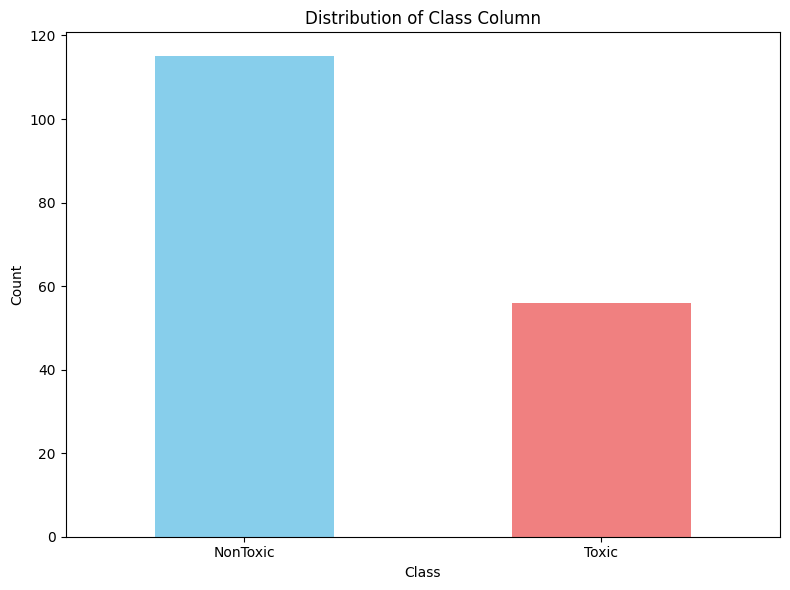

In [5]:
print("Unique values in 'Class' column:")
print(df['Class'].unique())

print("\nFrequency distribution of 'Class' column:")
class_counts = df['Class'].value_counts()
print(class_counts)

plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Class Column')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
#Encode "Class" Column
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['Class'] = label_encoder.fit_transform(df['Class'])

print("DataFrame after encoding 'Class' column:")
print(df.head())

DataFrame after encoding 'Class' column:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ET

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171 entries, 0 to 170
Columns: 1204 entries, MATS3v to Class
dtypes: float64(1003), int64(201)
memory usage: 1.6 MB
None


In [8]:
#prepare for data modelling
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (171, 1203)
Shape of y (target): (171,)


In [9]:
#feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Instantiate SelectKBest with f_classif and select a suitable number of features
# Choosing k=50 as an example, but this can be adjusted based on further analysis.
selector = SelectKBest(score_func=f_classif, k=50)

# Fit the selector to the features (X) and target (y)
selector.fit(X, y)

# Transform X to get the selected features
X_selected = selector.transform(X)

# Convert X_selected back to a DataFrame with selected column names for better readability
selected_feature_names = X.columns[selector.get_support()]
X_selected = pd.DataFrame(X_selected, columns=selected_feature_names)

print(f"Shape of X_selected (features after selection): {X_selected.shape}")

Shape of X_selected (features after selection): (171, 50)



Classification Report for GradientBoostingClassifier:
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       115
           1       0.35      0.27      0.30        56

    accuracy                           0.60       171
   macro avg       0.51      0.51      0.51       171
weighted avg       0.57      0.60      0.58       171



<Figure size 800x600 with 0 Axes>

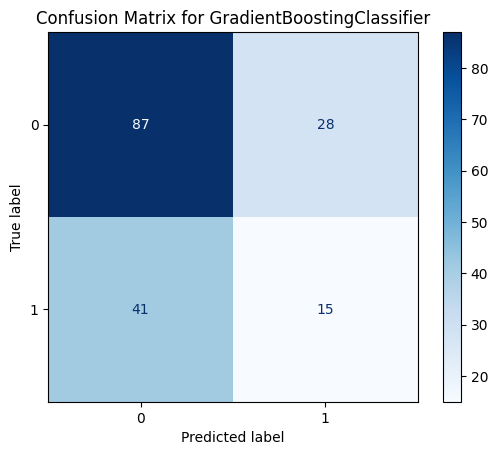

<Figure size 800x600 with 0 Axes>

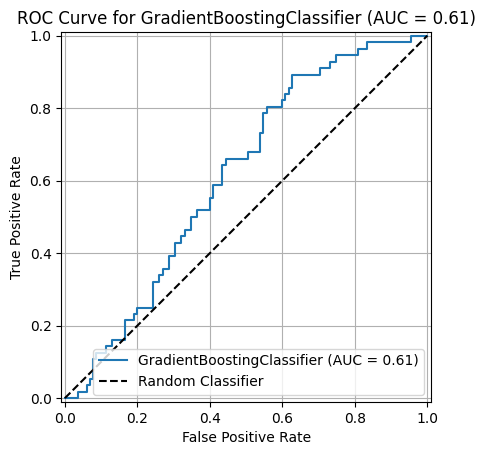

In [11]:
#Train and evaluate model with cross validation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Instantiate a GradientBoostingClassifier model with random_state=42
model_gb = GradientBoostingClassifier(random_state=42)

# Use cross_val_predict with cv=5 to get cross-validated predictions and probability estimates
y_pred_gb = cross_val_predict(model_gb, X_selected, y, cv=5)
y_prob_gb = cross_val_predict(model_gb, X_selected, y, cv=5, method='predict_proba')[:, 1]

# Print a classification report
print("\nClassification Report for GradientBoostingClassifier:")
print(classification_report(y, y_pred_gb))

# Generate and display the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred_gb, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for GradientBoostingClassifier')
plt.grid(False)
plt.show()

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y, y_prob_gb)

# Calculate the Area Under the Curve (AUC)
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr_gb, tpr=tpr_gb, roc_auc=roc_auc_gb, estimator_name='GradientBoostingClassifier').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve for GradientBoostingClassifier (AUC = {roc_auc_gb:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [12]:
#prepare data for modelling
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target): {y.shape}")

Shape of X (features): (171, 1203)
Shape of y (target): (171,)



Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       115
           1       0.38      0.27      0.32        56

    accuracy                           0.62       171
   macro avg       0.54      0.53      0.53       171
weighted avg       0.59      0.62      0.60       171



<Figure size 800x600 with 0 Axes>

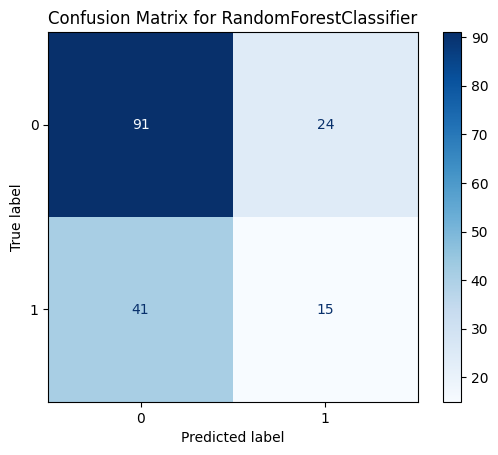

<Figure size 800x600 with 0 Axes>

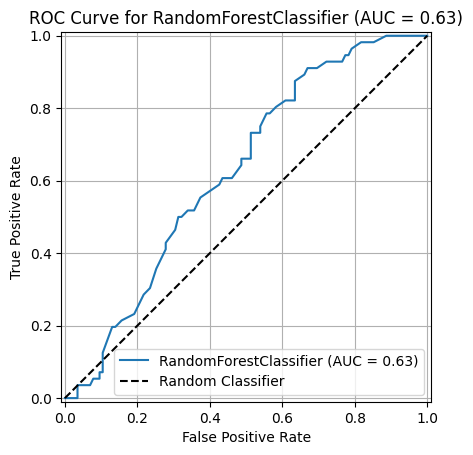

In [13]:
#train and evaluate model with cross validation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# Instantiate a RandomForestClassifier model with random_state=42
model_rf = RandomForestClassifier(random_state=42)

# Use cross_val_predict with cv=5 to get cross-validated predictions and probability estimates
y_pred_rf = cross_val_predict(model_rf, X_selected, y, cv=5)
y_prob_rf = cross_val_predict(model_rf, X_selected, y, cv=5, method='predict_proba')[:, 1]

# Print a classification report
print("\nClassification Report for RandomForestClassifier:")
print(classification_report(y, y_pred_rf))

# Generate and display the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred_rf, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for RandomForestClassifier')
plt.grid(False)
plt.show()

# Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y, y_prob_rf)

# Calculate the Area Under the Curve (AUC)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf, roc_auc=roc_auc_rf, estimator_name='RandomForestClassifier').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve for RandomForestClassifier (AUC = {roc_auc_rf:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Hyperparameter tuning for **RandomforestClassifier**

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 2. Define a parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt'], # 'auto' is deprecated, 'sqrt' is equivalent
    'min_samples_leaf': [1, 2, 4]
}

# 3. Instantiate RandomForestClassifier with random_state=42
rf_model = RandomForestClassifier(random_state=42)

# 4. Instantiate GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc',
                           n_jobs=-1,  # Use all available processors
                           verbose=1)

# 5. Fit GridSearchCV to the selected features (X_selected) and target variable (y)
grid_search.fit(X_selected, y)

# 6. Print the best parameters found by GridSearchCV
print("Best parameters found: ", grid_search.best_params_)

# 7. Print the best ROC AUC score achieved by the best model
print("Best ROC AUC score: ", grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters found:  {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}
Best ROC AUC score:  0.6788537549407114


Evaluate tuned randomForestClassifier


Classification Report for Tuned RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.69      0.80      0.74       115
           1       0.39      0.27      0.32        56

    accuracy                           0.63       171
   macro avg       0.54      0.53      0.53       171
weighted avg       0.59      0.63      0.60       171



<Figure size 800x600 with 0 Axes>

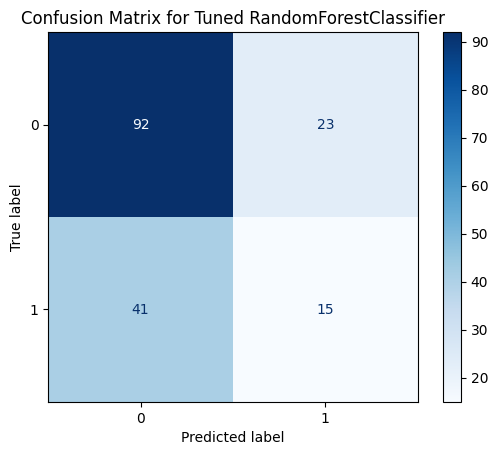

<Figure size 800x600 with 0 Axes>

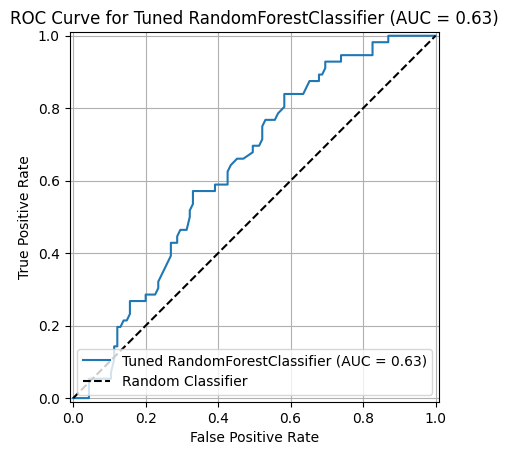

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Retrieve the best estimator from the grid_search object
best_rf_model = grid_search.best_estimator_

# 2. Use cross_val_predict to get cross-validated predictions
y_pred_tuned_rf = cross_val_predict(best_rf_model, X_selected, y, cv=5)

# 3. Use cross_val_predict to get probability estimates for the positive class
y_prob_tuned_rf = cross_val_predict(best_rf_model, X_selected, y, cv=5, method='predict_proba')[:, 1]

# 4. Print a classification report
print("\nClassification Report for Tuned RandomForestClassifier:")
print(classification_report(y, y_pred_tuned_rf))

# 5. Create a new figure and display the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred_tuned_rf, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned RandomForestClassifier')
plt.grid(False)
plt.show()

# 6. Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_tuned_rf, tpr_tuned_rf, thresholds_tuned_rf = roc_curve(y, y_prob_tuned_rf)

# 7. Calculate the Area Under the Curve (AUC)
roc_auc_tuned_rf = auc(fpr_tuned_rf, tpr_tuned_rf)

# 8. Create a new figure and plot the ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr_tuned_rf, tpr=tpr_tuned_rf, roc_auc=roc_auc_tuned_rf, estimator_name='Tuned RandomForestClassifier').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve for Tuned RandomForestClassifier (AUC = {roc_auc_tuned_rf:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


Hyperparameter tuning for gradientBoostingClassifier

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# 2. Define a parameter grid for GradientBoostingClassifier
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# 3. Instantiate GradientBoostingClassifier with random_state=42
gbc_model = GradientBoostingClassifier(random_state=42)

# 4. Instantiate GridSearchCV
grid_search_gb = GridSearchCV(estimator=gbc_model,
                              param_grid=param_grid_gb,
                              cv=5,
                              scoring='roc_auc',
                              n_jobs=-1,  # Use all available processors
                              verbose=1)

# 5. Fit GridSearchCV to the selected features (X_selected) and target variable (y)
grid_search_gb.fit(X_selected, y)

# 6. Print the best parameters found by GridSearchCV
print("Best parameters found for GradientBoostingClassifier: ", grid_search_gb.best_params_)

# 7. Print the best ROC AUC score achieved by the best model
print("Best ROC AUC score for GradientBoostingClassifier: ", grid_search_gb.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters found for GradientBoostingClassifier:  {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
Best ROC AUC score for GradientBoostingClassifier:  0.6467061923583662


Evaluate tuned gradientboostingClassifier


Classification Report for Tuned GradientBoostingClassifier:
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       115
           1       0.38      0.29      0.33        56

    accuracy                           0.61       171
   macro avg       0.54      0.53      0.53       171
weighted avg       0.59      0.61      0.60       171



<Figure size 800x600 with 0 Axes>

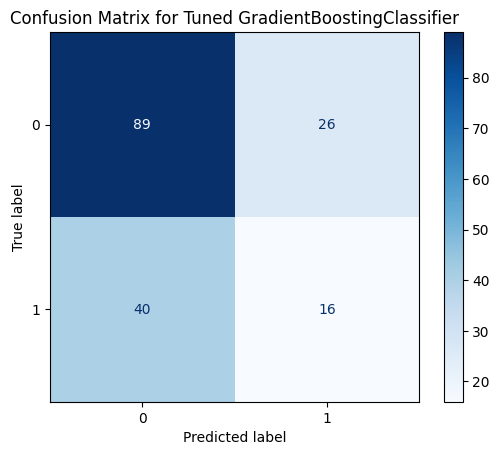

<Figure size 800x600 with 0 Axes>

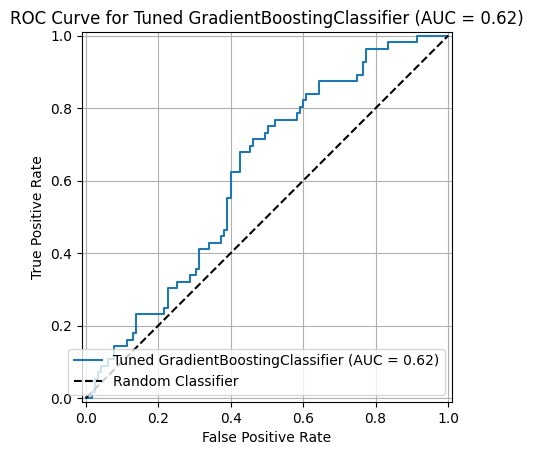

In [17]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Retrieve the best estimator from the grid_search_gb object
best_gb_model = grid_search_gb.best_estimator_

# 2. Use cross_val_predict to get cross-validated predictions
y_pred_tuned_gb = cross_val_predict(best_gb_model, X_selected, y, cv=5)

# 3. Use cross_val_predict to get probability estimates for the positive class
y_prob_tuned_gb = cross_val_predict(best_gb_model, X_selected, y, cv=5, method='predict_proba')[:, 1]

# 4. Print a classification report
print("\nClassification Report for Tuned GradientBoostingClassifier:")
print(classification_report(y, y_pred_tuned_gb))

# 5. Create a new figure and display the confusion matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y, y_pred_tuned_gb, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned GradientBoostingClassifier')
plt.grid(False)
plt.show()

# 6. Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr_tuned_gb, tpr_tuned_gb, thresholds_tuned_gb = roc_curve(y, y_prob_tuned_gb)

# 7. Calculate the Area Under the Curve (AUC)
roc_auc_tuned_gb = auc(fpr_tuned_gb, tpr_tuned_gb)

# 8. Create a new figure and plot the ROC curve
plt.figure(figsize=(8, 6))
RocCurveDisplay(fpr=fpr_tuned_gb, tpr=tpr_tuned_gb, roc_auc=roc_auc_tuned_gb, estimator_name='Tuned GradientBoostingClassifier').plot()
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.title(f'ROC Curve for Tuned GradientBoostingClassifier (AUC = {roc_auc_tuned_gb:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Final Project Report

## 1. Initial Data Preprocessing and Exploratory Data Analysis (EDA)

### Data Overview:
*   The dataset contained 171 entries and 1204 columns. There were no missing values across any columns and no duplicate rows, indicating good data completeness and integrity.

### Target Variable Analysis:
*   The 'Class' column, which is the target variable, was identified as the only categorical feature. It contained two unique values: 'NonToxic' and 'Toxic'.
*   The distribution of the 'Class' column showed a significant class imbalance: 115 instances of 'NonToxic' (Class 0) and 56 instances of 'Toxic' (Class 1).

### Preprocessing Steps:
*   The 'Class' column was successfully encoded into a numerical representation (0 for 'NonToxic' and 1 for 'Toxic') using `LabelEncoder`.

### Insights from EDA:
*   The dataset is clean in terms of missing values and duplicates.
*   The class imbalance in the target variable is a critical issue that needs to be addressed to prevent model bias towards the majority class.

## 2. Feature Selection

### Process:
*   The features (X) were separated from the target variable (y).
*   Feature selection was performed using `SelectKBest` with the `f_classif` scoring function.
*   The number of features was reduced from 1203 to 50, aiming to retain the most relevant features and reduce dimensionality.

### Outcome:
*   A reduced feature set (`X_selected`) of shape (171, 50) was created for model training.

## 3. Model Training and Evaluation (Untuned Models)

### A. RandomForestClassifier (Untuned):
*   **Performance Metrics (5-fold cross-validation):**
    *   Accuracy: 0.62
    *   Precision (Class 0): 0.69, Precision (Class 1): 0.38
    *   Recall (Class 0): 0.79, Recall (Class 1): 0.27
    *   F1-score (Class 0): 0.74, F1-score (Class 1): 0.32
    *   ROC AUC: 0.52
*   **Weaknesses:** The untuned RandomForestClassifier showed very poor performance in identifying the minority 'Toxic' class, with low recall and F1-score for Class 1. The ROC AUC of 0.52 suggested its discriminative ability was only marginally better than random guessing.

### B. GradientBoostingClassifier (Untuned):
*   **Performance Metrics (5-fold cross-validation):**
    *   Accuracy: 0.60
    *   Precision (Class 0): 0.68, Precision (Class 1): 0.35
    *   Recall (Class 0): 0.76, Recall (Class 1): 0.27
    *   F1-score (Class 0): 0.72, F1-score (Class 1): 0.30
    *   ROC AUC: 0.61
*   **Weaknesses:** Similar to the RandomForestClassifier, the untuned GradientBoostingClassifier also struggled with the minority 'Toxic' class, exhibiting low recall and F1-score. Its ROC AUC was slightly better than RandomForest but still low at 0.61.

## 4. Hyperparameter Tuning

### A. Tuned RandomForestClassifier (RFC):
*   **Tuning Method:** `GridSearchCV` with 5-fold cross-validation, optimizing for ROC AUC.
*   **Best Parameters Found:** `{'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}`.
*   **Best ROC AUC Score (from GridSearch):** 0.679
*   **Final Performance (5-fold cross-validation with best estimator):**
    *   Accuracy: 0.63
    *   Precision (Class 0): 0.69, Precision (Class 1): 0.39
    *   Recall (Class 0): 0.80, Recall (Class 1): 0.27
    *   F1-score (Class 0): 0.74, F1-score (Class 1): 0.32
    *   ROC AUC: 0.63
*   **Insights:** Hyperparameter tuning significantly improved the ROC AUC from 0.52 to 0.679 (GridSearchCV score) and 0.63 (cross-validated score). However, the model still demonstrated low recall and F1-score for the minority class, indicating a persistent challenge in correctly identifying positive instances.

### B. Tuned GradientBoostingClassifier (GBC):
*   **Tuning Method:** `GridSearchCV` with 5-fold cross-validation, optimizing for ROC AUC.
*   **Best Parameters Found:** `{'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}`.
*   **Best ROC AUC Score (from GridSearch):** 0.647
*   **Final Performance (5-fold cross-validation with best estimator):**
    *   Accuracy: 0.61
    *   Precision (Class 0): 0.69, Precision (Class 1): 0.38
    *   Recall (Class 0): 0.77, Recall (Class 1): 0.29
    *   F1-score (Class 0): 0.73, F1-score (Class 1): 0.33
    *   ROC AUC: 0.62
*   **Insights:** Tuning provided a modest improvement in ROC AUC from 0.61 to 0.647 (GridSearchCV score) and 0.62 (cross-validated score). Similar to the tuned RFC, the GBC also struggled with the minority class, showing low recall and F1-score.

## 5. Overall Comparison and Conclusion

*   **Model Performance:** The Tuned RandomForestClassifier generally outperformed the Tuned GradientBoostingClassifier in terms of ROC AUC (0.63 vs. 0.62). Both models showed improved performance after hyperparameter tuning compared to their untuned versions.
*   **Strengths:** Both tuned models were able to identify the majority class ('NonToxic') with reasonable precision and recall.
*   **Weaknesses:** A consistent challenge for both models, even after tuning, was the poor performance in predicting the minority 'Toxic' class, evidenced by low recall and F1-scores. This is likely due to the inherent class imbalance in the dataset.

## 6. Next Steps and Recommendations

*   **Address Class Imbalance:** The most critical next step is to aggressively address the class imbalance. Techniques such as SMOTE (Synthetic Minority Over-sampling Technique), ADASYN, or adjusting class weights within the models should be explored. These methods can be integrated directly into the cross-validation pipeline during model training.
*   **Further Hyperparameter Tuning:** Explore a wider range of hyperparameters or finer grids for both models, potentially including `max_depth` for RandomForestClassifier and additional parameters for GradientBoostingClassifier.
*   **Explore Other Algorithms:** Investigate other classification algorithms that might be more robust to imbalanced data or better suited for the dataset's characteristics (e.g., SVM, XGBoost, LightGBM, CatBoost).
*   **Advanced Feature Engineering:** Further analyze the selected features and consider creating new features from the existing ones that might provide more discriminative power for predicting toxicity.
*   **Ensemble Methods/Stacking:** Consider combining the predictions of multiple models (e.g., the tuned RandomForest and GradientBoosting models) using ensemble or stacking techniques to potentially achieve higher performance.
*   **Domain Expertise:** If possible, consult domain experts to gain deeper insights into the features and the nature of toxicity, which could guide further feature engineering or model selection.